# Q_LSTM — Quantile LSTM for RUL Prediction

LSTM — cell state + forget gate for long-range dependencies.
Standard choice in PHM literature for RUL prediction.

**Structure:** Same as DL notebooks (MLP.ipynb, GRU.ipynb, etc.) but:
- Loss: **Pinball loss** instead of NASA asymmetric loss
- Output: **3 neurons** (Q10, Q50, Q90) instead of 1
- Evaluation: Q50 used for RMSE/NASA; Q10-Q90 interval for uncertainty quantification

## 1. Imports & Setup

In [ ]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root


In [ ]:
from src.models.deep_learning import (
    load_data, select_features, build_windows, engine_split,
    make_loaders, train_quantile_model, predict_quantiles,
    evaluate_quantile_model, plot_quantile_predictions,
    plot_loss_curves, DEVICE, EPOCHS, LR, PATIENCE, BATCH_SIZE,
)
from src.evaluation.metrics import (
    evaluate, save_model_results, pinball_loss_by_quantile, reliability_diagram,
)
import torch.nn as nn

print(f"Device: {DEVICE}")


Device: mps


In [ ]:
import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
print(f"Seeds fixed: {SEED}")


Seeds fixed: 42


In [ ]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)
print(f"Features: {N_FEATURES}  Train engines: {train_df['engine_id'].nunique()}  Test engines: {test_df['engine_id'].nunique()}")

Train shape : (61249, 123)  (249 engines)
Test  shape : (41214, 123)   (248 engines)
Feature columns (48): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's6_rmean_5', 's7_rmean_5'] ...
Features: 48  Train engines: 249  Test engines: 248


## 2. Load Data

## 3. Build Sliding Windows (30-cycle, engine-split 80/20)

In [ ]:
X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)
X_test,  y_test  = build_windows(test_df, FEAT_COLS, is_test=True)
print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')

Train engines: 199  Val engines: 50
X_train: (43750, 30, 48)  X_val: (50, 30, 48)
X_train: (43750, 30, 48)  X_val: (50, 30, 48)  X_test: (248, 30, 48)


## 4. DataLoaders

In [ ]:
train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)

Train batches: 342  Val batches: 1


## 5. Model Definition — QuantileLSTM

In [ ]:
from src.models.dl_architectures import QuantileLSTM


In [ ]:
model = QuantileLSTM(n_features=N_FEATURES, dropout=0.1)
QUANTILES = [0.1, 0.5, 0.9]
print(model)

QuantileLSTM(
  (lstm): LSTM(48, 64, num_layers=2, batch_first=True, dropout=0.1)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


## 6. Training with Pinball Loss

  [Q_LSTM] Epoch  10 | train=1.8552 | val=5.9618 | best=5.4906  [Pinball]
  [Q_LSTM] Early stop at epoch 17


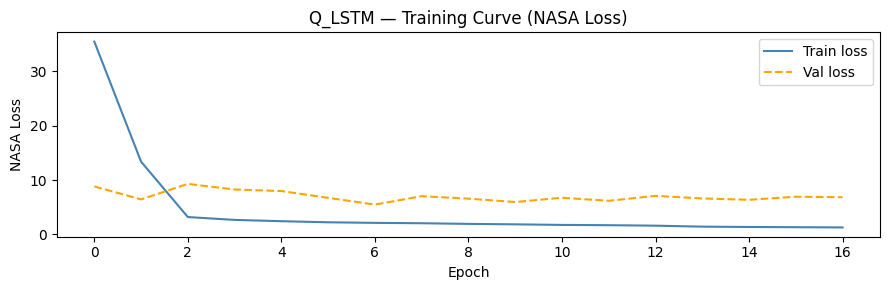

In [ ]:
model, train_losses, val_losses = train_quantile_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    quantiles    = QUANTILES,
    epochs       = EPOCHS,
    lr           = LR,
    model_name   = 'Q_LSTM',
)
plot_loss_curves(train_losses, val_losses, model_name='Q_LSTM')

## 7. Evaluation — Point Metrics (Q50) + Interval Metrics


=== Q_LSTM ===
  [Q_LSTM (Q50)] RMSE: 17.0377  |  NASA Score: 1529.67 (mean: 6.17)  |  R2: 0.8429  |  Bias: +5.42 (late ↑)
  Interval width (Q90-Q10) mean : 25.44 cycles
  80% interval coverage         : 60.9%  (target: ~80%)


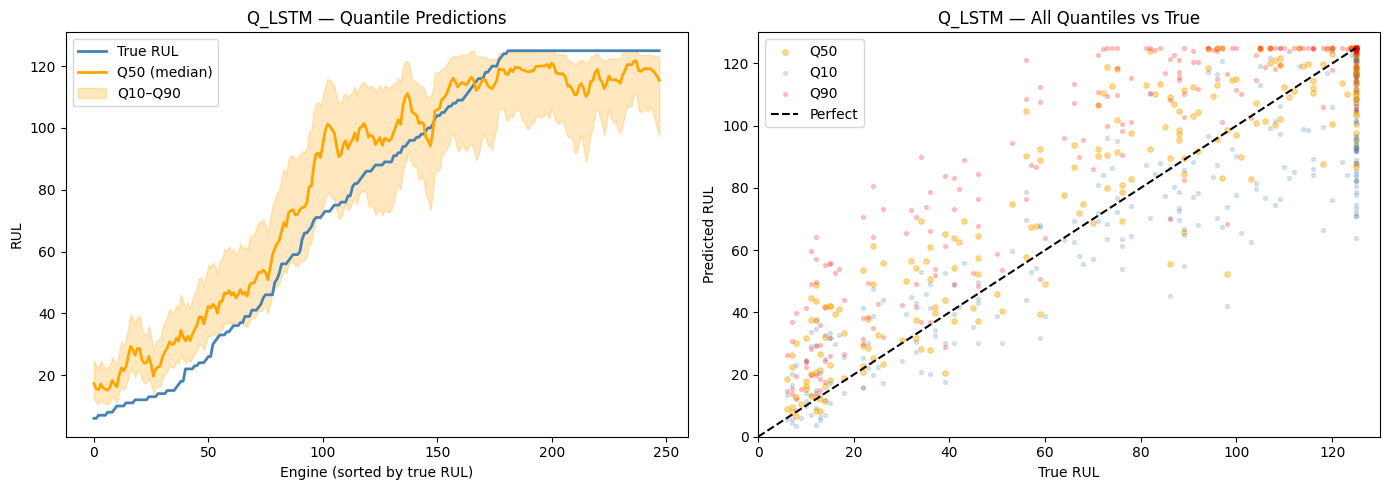

In [ ]:
y_true, q10, q50, q90 = predict_quantiles(model, test_loader)
results, width, coverage = evaluate_quantile_model(y_true, q10, q50, q90, model_name='Q_LSTM')
plot_quantile_predictions(y_true, q10, q50, q90, model_name='Q_LSTM')

## 8. Calibration Metrics

Addresses critic: *'No calibration metrics — coverage probability, pinball loss missing'*


Pinball Loss by Quantile — Q_LSTM
   Q10   Q50    Q90
4.1309 6.297 2.3498


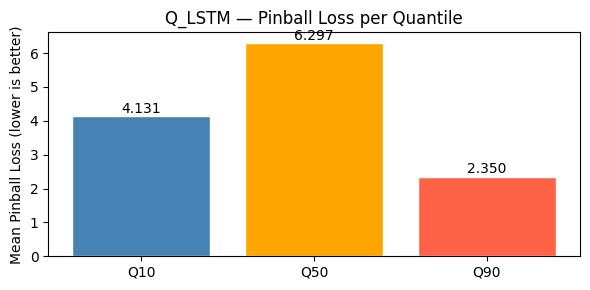

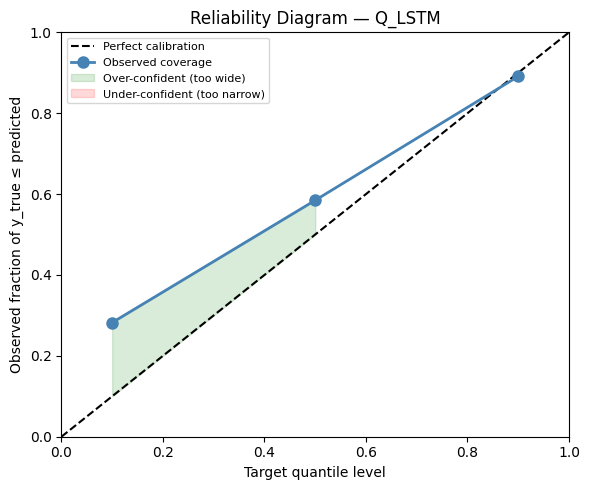

  Mean Calibration Error (MCE): 0.0919  (0=perfect, closer=better)

Interval Coverage by RUL Bucket — Q_LSTM
RUL bucket  n_engines  coverage_%  mean_width  median_width
   [0, 25)         49        38.8       16.22         15.03
  [25, 50)         30        56.7       24.90         25.36
 [50, 100)         67        61.2       35.13         36.94
[100, 125)         35        74.3       28.06         34.63

Note: wider intervals in early life (RUL 50-125) reflect genuine
epistemic uncertainty — model has less certainty about long-horizon predictions.


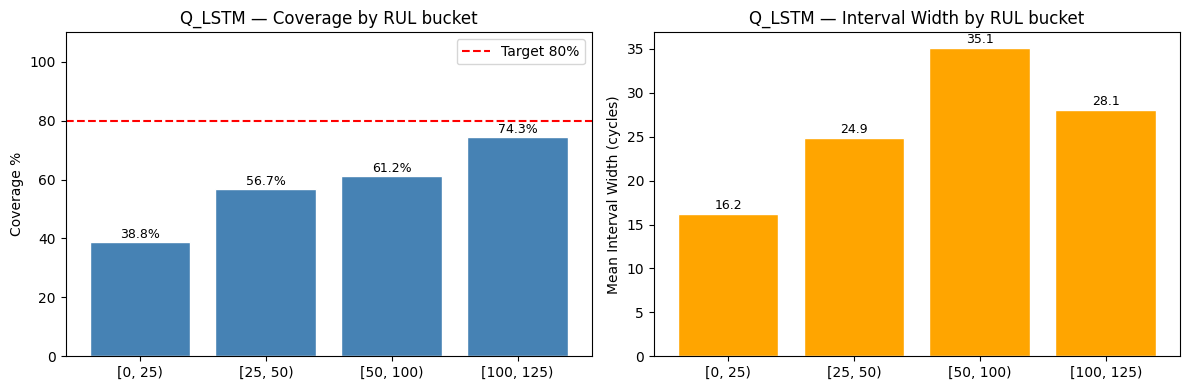

In [ ]:
from src.evaluation.metrics import pinball_loss_by_quantile, reliability_diagram, interval_coverage_by_rul_bucket
import numpy as np

# Pinball loss per quantile
preds_matrix = np.stack([q10, q50, q90], axis=1)
pinball_df = pinball_loss_by_quantile(y_true, preds_matrix, QUANTILES, model_name='Q_LSTM')

# Reliability diagram
all_q_preds = {0.1: q10, 0.5: q50, 0.9: q90}
reliability_diagram(y_true, all_q_preds, title='Reliability Diagram — Q_LSTM')

# Interval coverage by RUL bucket
bucket_df = interval_coverage_by_rul_bucket(y_true, q10, q90, model_name='Q_LSTM')

## 9. Save Results to CSV

In [ ]:
save_model_results(
    model_name = 'Q_LSTM',
    model_type = 'quantile',
    y_true     = y_true,
    y_pred     = q50,
    q10        = q10,
    q90        = q90,
)
print('Results saved to results/all_model_results.csv')

  [Q_LSTM] RMSE: 17.0377  |  NASA Score: 1529.67 (mean: 6.17)  |  R2: 0.8429  |  Bias: +5.42 (late ↑)
  → Saved to results/all_model_results.csv
Results saved to results/all_model_results.csv


In [ ]:
from src.evaluation.metrics import save_predictions_csv
import numpy as np

engine_ids = list(range(len(y_true)))
save_predictions_csv(
    engine_ids = engine_ids,
    y_true     = y_true,
    y_pred     = q50,
    y_lower    = q10,
    y_upper    = q90,
    model_name = "Q_LSTM",
)



  [Q_LSTM] Bound Validation Report (248 engines):
    ✓ negative_preds: 0
    ✓ over_cap_preds: 0
    ✓ inverted_bounds: 0
    ✓ pred_outside_interval: 0
    ✓ nan_or_inf: 0
    → All checks passed — predictions are numerically valid.
  → Saved 248 predictions to results/predictions/Q_LSTM.csv
     Coverage: 60.9%  |  Avg interval width: 25.44 cycles


PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/predictions/Q_LSTM.csv')